In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Base vs aligned: does instruction tuning create the preferences, or amplify them?

`qwen-pt` 7B (the **base** model, `Qwen/Qwen2.5-7B`) against `qwen` 7B (the **aligned** model,
`Qwen/Qwen2.5-7B-instruct`), on the same 45 laptops and the same four contracts.

Method is the same as `figs4deck5_fix.ipynb`: zero-mean feature weights, positional bias kept
separate, every "who wins" question answered position-corrected. `scores.csv` is read, never
written.

**One thing must be handled before any number is comparable.** The two families were collected
under **different PMI regimes**:

| | PMI | consequence |
|---|---|---|
| `qwen` (aligned), collected before 2026-08-12 | **on** | stored margins carry a constant `-C`; the fitted intercept is `gamma - C` |
| `qwen-pt` (base), collected 2026-08-16 | **off** | stored margins are raw; the fitted intercept **is** `gamma` |

So `C` is recovered for the aligned runs and set to **exactly 0** for the base runs. The cell
below checks that assumption rather than trusting it: with PMI off every stored score is a bare
log-probability and must be `<= 0`.

**A caveat that applies to everything here.** Base and aligned differ in four things at once —
instruction tuning, the chat template, the system message, and the prompt wording (the base runs
use the `pretrained` template set, which ends mid-sentence). A base model has no chat template,
so these cannot be separated. Read every result as *base pipeline vs aligned pipeline*.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerTuple

SAVE = True
FIGDIR = "figs/pt_vs_instruct"
os.makedirs(FIGDIR, exist_ok=True)

BASES = ["data/laptops_robustness", "data/laptops_robustness_pt"]
BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
SC = ["13-inch", "14-inch", "16-inch"]
RM = ["4GB", "8GB", "16GB"]
LEVELS = {"brand": BRANDS, "screen": SC, "ram": RM}
CON = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
CLAB = dict(zip(CON, ["none", "14in", "8GB", "14in+8GB"]))
cols = [CLAB[c] for c in CON]

# the two runs being compared: (family, size) -> label
PAIR = {("qwen-pt", "7"): "base", ("qwen", "7"): "aligned"}
KINDS = ["base", "aligned"]

BRAND_COLOR = dict(zip(BRANDS, ["#2a78d6", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
BRAND_MARKER = dict(zip(BRANDS, ["o", "s", "^", "D", "v"]))
FEATURE_COLOR = {"brand": "#2a78d6", "screen": "#eb6834", "ram": "#1baf7a"}
KIND_COLOR = {"base": "#8a6bbf", "aligned": "#2a78d6"}
KIND_MARKER = {"base": "o", "aligned": "s"}
SATISFY, VIOLATE = "#2a78d6", "#e34948"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#d6d5d1", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": True, "grid.color": "#e8e7e3", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
    "font.size": 10, "savefig.bbox": "tight", "savefig.dpi": 200,
})
pd.set_option("display.width", 220)

def save(fig, name):
    if SAVE:
        fig.savefig(os.path.join(FIGDIR, name + ".png"), facecolor=SURFACE)
    return fig

## Notation

**The fit.** One row is one ordered pair; the margin is $m(a,b) = \text{score}_a - \text{score}_b$.

$$m_{\text{raw}}(a,b) = \gamma + u(a) - u(b) + \varepsilon,
\qquad u(x) = \sum_f w_f(x_f), \qquad \sum_{\ell} w_f(\ell) = 0 .$$

**The PMI constant.** What is stored is $m_{\text{stored}} = m_{\text{raw}} - C$, so the fitted
intercept is $\gamma - C$ and $\gamma = \hat{\gamma}_{\text{fit}} + C$. For the aligned runs
$C$ is recovered from saturation, $\hat{C} = \max_i \text{score}_b^{(i)} - \max_i \text{score}_a^{(i)}$;
for the base runs PMI was never applied, so $C = 0$ exactly.

**Position correction.** Each unordered pair is shown in both slot orders, so

$$D(x,y) = \tfrac{1}{2}\left[\, m(x,y) - m(y,x) \,\right] = u(x) - u(y)$$

which is immune to $\gamma$, to $C$, and to any other constant.

### Comparing two models whose scales differ

The weight scale is a **nuisance parameter** (progress.md 2026-08-12): a model can be *louder*
without preferring anything differently. Raw log-odds therefore cannot be compared between base
and aligned. Everything below is one of three scale-free quantities.

**1. Normalised weight.** With $S$ the model's total spread on that run,

$$S = \sum_f \left[\max_{\ell} w_f(\ell) - \min_{\ell} w_f(\ell)\right],
\qquad \tilde{w}_f(\ell) = \frac{w_f(\ell)}{S} .$$

$\tilde{w}$ says what *share* of the model's total preference range this level accounts for. Two
models with identical $\tilde{w}$ want exactly the same things; only their volume differs.

**2. Relative positional bias.** $|\gamma| / S$ — how big the slot artefact is next to the
model's own preferences. Comparing raw $|\gamma|$ across a 10x scale difference is meaningless.

**3. The adherence pair**, exactly as in `figs4deck5_fix.ipynb`: over the conflict pairs $S$,

$$A = \frac{100}{|S|}\sum \mathbf{1}\!\left[\, D > 0 \,\right],
\qquad g = \frac{1}{|S|}\sum D, \qquad \kappa = 1 - \frac{g_1}{g_0}$$

both already scale-free ($A$ is a count, $\kappa$ is a ratio of two gaps from the same model).

In [3]:
# Frame pinned: both models must be compared on the same frame, and every constrained run
# uses "shopping". Since the bare-frame runs landed, `constraints_id` is "none" for both the
# shopping and the bare unconstrained run, so (family, size, constraints_id) is no longer a
# unique key - the assert makes a collision loud instead of silent.
FRAME = "shopping"


def load(frame=FRAME):
    """Runs on the `frame` frame, keyed by (family, size, constraints_id).
    scores.csv is read, never written."""
    R = {}
    for base in BASES:
        for run in sorted(os.listdir(base)):
            cp = os.path.join(base, run, "config.json")
            if not os.path.isfile(cp):
                continue
            c = json.load(open(cp))
            if c["frame"]["name"] != frame:
                continue
            key = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            if key[:2] in PAIR and key[2] in CON:
                assert key not in R, f"two runs share the key {key}; the key is not unique"
                R[key] = pd.read_csv(os.path.join(base, run, "scores.csv"))
    return R


def pmi_offset(runs, tol=0.01):
    """C recovered from saturation: a saturated prompt has logP ~ 0, so max(score) ~ -logP(L|base)."""
    mA = max(d.score_a.max() for d in runs)
    mB = max(d.score_b.max() for d in runs)
    sat = min(max((d.score_a > mA - tol).mean() for d in runs),
              max((d.score_b > mB - tol).mean() for d in runs))
    return mB - mA, sat, mA, mB


RUNS = load()
PMI_C = {}
print("PMI regime check - with PMI off every stored score is a bare log-prob, so max <= 0:\n")
for (fam, size), kind in PAIR.items():
    rs = [RUNS[(fam, size, c)] for c in CON]
    chat, sat, mA, mB = pmi_offset(rs)
    pmi_on = (mA > 0) or (mB > 0)
    # base runs: PMI was never applied (PretrainedHFAgent has no PMI block), so C is 0 by
    # construction - not estimated. The max<=0 check is what verifies that.
    PMI_C[(fam, size)] = chat if pmi_on else 0.0
    print(f"  {kind:8} {fam:8} max score_a={mA:8.4f}  max score_b={mB:8.4f}  "
          f"-> PMI {'ON ' if pmi_on else 'OFF'}  C = {PMI_C[(fam, size)]:.3f}"
          f"{'  (recovered, saturation %.2f)' % sat if pmi_on else '  (exact)'}")

assert PMI_C[("qwen-pt", "7")] == 0.0, "base runs should have no PMI offset"
print(f"\n{len(RUNS)} runs loaded ({len(PAIR)} models x {len(CON)} contracts), 9900 rows each.")

PMI regime check - with PMI off every stored score is a bare log-prob, so max <= 0:

  base     qwen-pt  max score_a= -0.0026  max score_b= -0.0007  -> PMI OFF  C = 0.000  (exact)
  aligned  qwen     max score_a=  0.0695  max score_b=  6.0703  -> PMI ON   C = 6.001  (recovered, saturation 0.40)

8 runs loaded (2 models x 4 contracts), 9900 rows each.


## The model

Same `FeatureBT` as `figs4deck5_fix.ipynb`, plus `total_spread` and `normalised` for the
scale-free comparison.

In [4]:
import warnings


class FeatureBT:
    """Feature-based Bradley-Terry with a positional bias, fitted by OLS on score margins.

    weights_[feature][level] : every level, centred to mean 0 within the feature
    gamma_fit_ / gamma_      : intercept as fitted (= gamma - C), and corrected (+ pmi_c)
    """

    def __init__(self, pmi_c=0.0, r2_warn=0.5, verbose=False):
        self.pmi_c = pmi_c
        self.r2_warn = r2_warn
        self.verbose = verbose

    def fit(self, df, a_prefix="a_", b_prefix="b_"):
        n = len(df)
        Y = (df["score_a"] - df["score_b"]).values

        cols_a = [c for c in df.columns if c.startswith(a_prefix)]
        cols_b = [c.replace(a_prefix, b_prefix) for c in cols_a]
        self.features_ = [c[len(a_prefix):] for c in cols_a]

        df_a = df[cols_a].rename(columns=dict(zip(cols_a, self.features_)))
        df_b = df[cols_b].rename(columns=dict(zip(cols_b, self.features_)))
        combined = pd.concat([df_a, df_b], axis=0)

        dummies = pd.get_dummies(combined, drop_first=True, dtype=float)
        X = sm.add_constant(dummies.iloc[:n].values - dummies.iloc[n:].values)

        self.result_ = sm.OLS(Y, X).fit()
        self.gamma_fit_ = self.result_.params[0]
        self.gamma_ = self.gamma_fit_ + self.pmi_c
        self.r2_ = self.result_.rsquared

        raw = dict(zip(dummies.columns.tolist(), self.result_.params[1:]))
        self.weights_ = {}
        for feat in self.features_:
            w = {lvl: raw.get(f"{feat}_{lvl}", 0.0) for lvl in combined[feat].unique()}
            mean = np.mean(list(w.values()))
            self.weights_[feat] = {lvl: v - mean for lvl, v in w.items()}

        if self.r2_ < self.r2_warn:
            warnings.warn(f"low fit: R^2 = {self.r2_:.3f} < {self.r2_warn}")
        return self

    def range(self, feat):
        w = self.weights_[feat]
        return max(w.values()) - min(w.values())

    def total_spread(self):
        """S: the model's whole preference range on this run, in log-odds."""
        return sum(self.range(f) for f in self.features_)

    def normalised(self, feat, level):
        """w / S - the share of the model's total range this level accounts for."""
        return self.weights_[feat][level] / self.total_spread()


FITS = {k: FeatureBT(pmi_c=PMI_C[k[:2]]).fit(d) for k, d in RUNS.items()}
KEY = {(kind, c): (fam, size, c)
       for (fam, size), kind in PAIR.items() for c in CON}

summary = pd.DataFrame([
    dict(kind=kind, contract=CLAB[c], r2=FITS[KEY[(kind, c)]].r2_,
         gamma_fit=FITS[KEY[(kind, c)]].gamma_fit_, gamma=FITS[KEY[(kind, c)]].gamma_,
         **{f"rng_{f}": FITS[KEY[(kind, c)]].range(f) for f in LEVELS},
         S=FITS[KEY[(kind, c)]].total_spread(),
         gamma_rel=abs(FITS[KEY[(kind, c)]].gamma_) / FITS[KEY[(kind, c)]].total_spread())
    for kind in KINDS for c in CON])
print(summary.round(3).to_string(index=False))
print("\nThe aligned model is about "
      f"{summary[summary.kind=='aligned'].S.mean() / summary[summary.kind=='base'].S.mean():.0f}x "
      "louder in raw log-odds. Everything below is scale-free for that reason.")

   kind contract    r2  gamma_fit  gamma  rng_brand  rng_screen  rng_ram      S  gamma_rel
   base     none 0.605     -0.170 -0.170      0.198       0.074    2.360  2.631      0.065
   base     14in 0.648     -0.303 -0.303      0.220       0.966    2.401  3.587      0.085
   base      8GB 0.739     -0.216 -0.216      0.134       0.125    2.683  2.942      0.074
   base 14in+8GB 0.725     -0.449 -0.449      0.188       1.168    2.089  3.446      0.130
aligned     none 0.864     -9.049 -3.048      0.858       3.900   26.526 31.284      0.097
aligned     14in 0.817     -8.980 -2.979      1.278       8.597   21.853 31.728      0.094
aligned      8GB 0.906     -8.106 -2.106      0.561       1.282   22.269 24.111      0.087
aligned 14in+8GB 0.799     -9.396 -3.396      1.139      12.526   16.535 30.199      0.112

The aligned model is about 9x louder in raw log-odds. Everything below is scale-free for that reason.


In [5]:
def paired_D(d, mask, a_is_candidate):
    """One D = u(candidate) - u(other) per unordered pair, position-corrected.

    The candidate sits in slot A in one row and slot B in the other, so averaging the two
    cancels gamma, the PMI constant, and any other additive constant.
    """
    m = (d.score_a - d.score_b).values
    A = (d.a_brand + "|" + d.a_screen + "|" + d.a_ram).values
    B = (d.b_brand + "|" + d.b_screen + "|" + d.b_ram).values
    first, second = np.where(A < B, A, B), np.where(A < B, B, A)
    key = np.char.add(np.char.add(first.astype(str), "##" + second.astype(str)),
                      "##" + d.template_idx.astype(str).values)
    t = pd.DataFrame({"key": key, "v": np.where(a_is_candidate, m, -m)})[np.asarray(mask)]
    g = t.groupby("key")["v"].agg(["mean", "size"])
    return g[g["size"] == 2]["mean"].values


def only_one(d, feat):
    """Rows where a and b differ in `feat` and are tied on every other feature."""
    m = (d[f"a_{feat}"] != d[f"b_{feat}"]).values.copy()
    for o in [f for f in ("brand", "screen", "ram") if f != feat]:
        m &= (d[f"a_{o}"] == d[f"b_{o}"]).values
    return m


def pair_of(d, feat, u, v):
    return (((d[f"a_{feat}"] == u) & (d[f"b_{feat}"] == v))
            | ((d[f"a_{feat}"] == v) & (d[f"b_{feat}"] == u))).values

---
# Fig PT-1 — adherence, split into the two directions the contract creates

Same measurement as Fig 5.5 D. A contract saying *8GB* makes two kinds of comparison:

| direction | pair | what obeying costs |
|---|---|---|
| **AGREE** | 8GB vs 4GB | nothing — contract and model want the same laptop |
| **CONFLICT** | 8GB vs 16GB | a RAM step — the model must give up something it wants |

**Which pairs.** Ceteris paribus: brand tied, the other spec feature tied. 5 brands x 3 levels of
the other feature x 5 templates = **75 unordered pairs** per bar. Height is $A$, computed from
$D$, so no positional bias is left in it. The red tick is the same conflict pairs with no
contract.

**The question this answers:** does a model that was never instruction-tuned respond to a stated
preference at all? Note that for a base model "obeying" is not obedience — it is *text
coherence*. The prompt is a document in which the speaker has already said *"I prefer 8 GB ram"*,
and the base model is completing that document consistently.

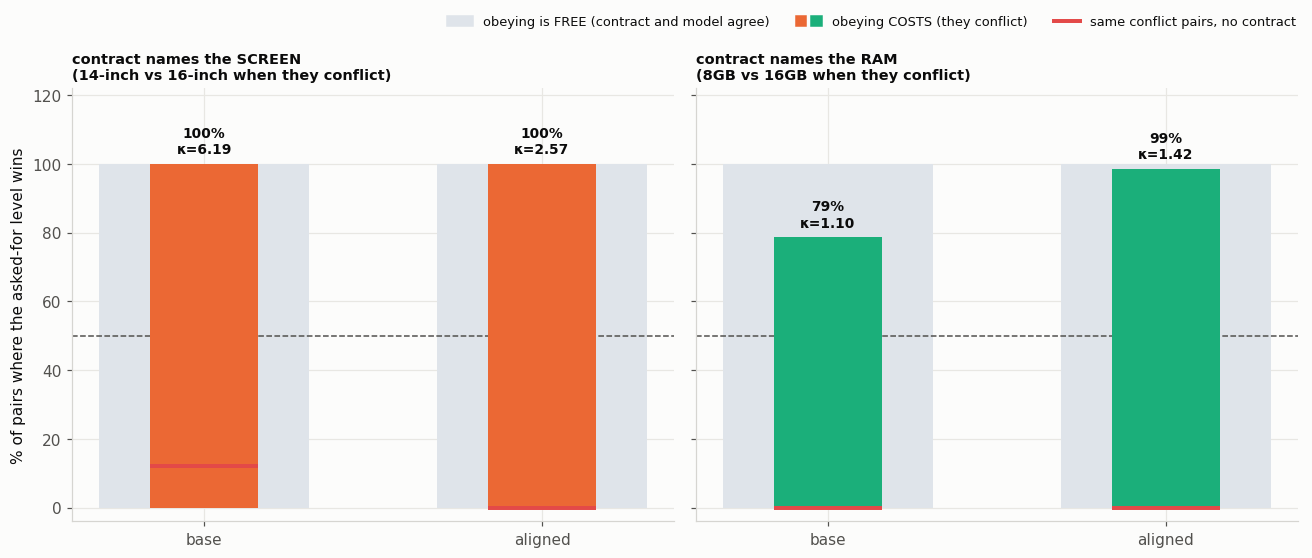

                n_pairs  before  conflict  agree     g0     g1  kappa
feat   kind                                                          
screen base          75    12.0    100.00  100.0  -0.29   1.49   6.19
ram    base          75     0.0     78.67  100.0  -1.94   0.18   1.10
screen aligned       75     0.0    100.00  100.0 -10.68  16.78   2.57
ram    aligned       75     0.0     98.67  100.0 -21.38   9.02   1.42


In [6]:
ASKED  = {"screen": "14-inch", "ram": "8GB"}
RIVAL  = {"screen": "16-inch", "ram": "16GB"}    # conflict: the model's own favourite
FRIEND = {"screen": "13-inch", "ram": "4GB"}     # agree: obeying is free
RUN_OF = {"screen": "screen=14-inch", "ram": "ram=8GB"}

rows = []
for kind in KINDS:
    for feat in ("screen", "ram"):
        d1, d0 = RUNS[KEY[(kind, RUN_OF[feat])]], RUNS[KEY[(kind, "none")]]
        w1 = (d1[f"a_{feat}"] == ASKED[feat]).values
        w0 = (d0[f"a_{feat}"] == ASKED[feat]).values
        Dc1 = paired_D(d1, only_one(d1, feat) & pair_of(d1, feat, ASKED[feat], RIVAL[feat]), w1)
        Dc0 = paired_D(d0, only_one(d0, feat) & pair_of(d0, feat, ASKED[feat], RIVAL[feat]), w0)
        Da1 = paired_D(d1, only_one(d1, feat) & pair_of(d1, feat, ASKED[feat], FRIEND[feat]), w1)
        g0, g1 = Dc0.mean(), Dc1.mean()
        rows.append(dict(kind=kind, feat=feat, n_pairs=len(Dc1),
                         before=100 * (Dc0 > 0).mean(),
                         conflict=100 * (Dc1 > 0).mean(),
                         agree=100 * (Da1 > 0).mean(),
                         g0=g0, g1=g1, kappa=1 - g1 / g0))
SPLIT = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, feat in zip(axes, ["screen", "ram"]):
    t = SPLIT[SPLIT.feat == feat].set_index("kind").reindex(KINDS)
    x = np.arange(len(t))
    ax.bar(x, t.agree, .62, color="#dfe4ea", zorder=2)
    ax.bar(x, t.conflict, .32, color=FEATURE_COLOR[feat], zorder=3)
    ax.hlines(t.before, x - .16, x + .16, color=VIOLATE, lw=2.6, zorder=5)
    for xi, (cf, kp) in enumerate(zip(t.conflict, t.kappa)):
        ax.text(xi, cf + 3, f"{cf:.0f}%\nκ={kp:.2f}", ha="center", fontsize=9,
                fontweight="bold")
    ax.axhline(50, color=INK_MUTED, ls="--", lw=1)
    ax.set_xticks(x, t.index)
    ax.set_ylim(-4, 122)
    # two lines: side by side these titles are too long to sit on one
    ax.set_title(f"contract names the {feat.upper()}\n"
                 f"({ASKED[feat]} vs {RIVAL[feat]} when they conflict)",
                 loc="left", fontweight="bold", fontsize=9.5)
axes[0].set_ylabel("% of pairs where the asked-for level wins")
costs = tuple(Rectangle((0, 0), 1, 1, color=FEATURE_COLOR[f]) for f in ("screen", "ram"))
fig.legend(handles=[Rectangle((0, 0), 1, 1, color="#dfe4ea"), costs,
                    Line2D([], [], color=VIOLATE, lw=2.6)],
           labels=["obeying is FREE (contract and model agree)",
                   "obeying COSTS (they conflict)",
                   "same conflict pairs, no contract"],
           handler_map={tuple: HandlerTuple(ndivide=None)},
           loc="upper right", ncol=3, frameon=False, fontsize=8.5,
           bbox_to_anchor=(.995, 1.06))
fig.tight_layout()
save(fig, "pt1_adherence_split")
plt.show()

print(SPLIT.set_index(["feat", "kind"]).round(2).to_string())

---
# Fig PT-2 — every brand's weight across the four contracts

Fig 6.2, run for both models. No contract mentions brand, so any movement here is the model
completing the contract with something the user never asked for — the main conjecture.

**Left two panels** are raw log-odds, each on its own axis (the scales differ ~10x, so a shared
axis would flatten the base model into a line). **Right panel** is the scale-free version: Apple's
weight as a share of that run's total spread, $\tilde{w}$, with both models on one axis.

The right panel is the one that answers the question. If instruction tuning *created* the Apple
effect, the base curve should be flat.

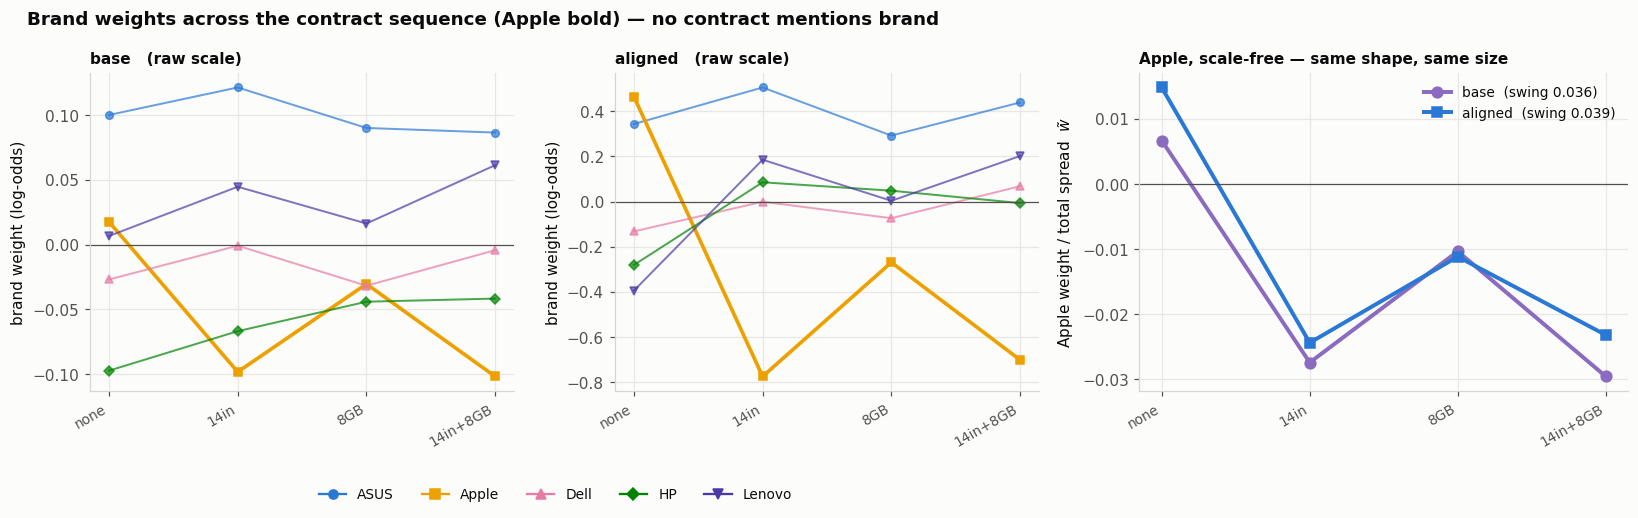

Apple's weight per contract:

   kind       unit   none    14in     8GB  14in+8GB  swing
   base        raw 0.0176 -0.0983 -0.0304   -0.1019 0.1194
   base normalised 0.0067 -0.0274 -0.0103   -0.0296 0.0362
aligned        raw 0.4641 -0.7737 -0.2691   -0.7005 1.2378
aligned normalised 0.0148 -0.0244 -0.0112   -0.0232 0.0392

Brand order, best to worst:
  base     none       ASUS > Apple > Lenovo > Dell > HP
  base     14in       ASUS > Lenovo > Dell > HP > Apple
  base     8GB        ASUS > Lenovo > Apple > Dell > HP
  base     14in+8GB   ASUS > Lenovo > Dell > HP > Apple
  aligned  none       Apple > ASUS > Dell > HP > Lenovo
  aligned  14in       ASUS > Lenovo > HP > Dell > Apple
  aligned  8GB        ASUS > HP > Lenovo > Dell > Apple
  aligned  14in+8GB   ASUS > Lenovo > Dell > HP > Apple


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4),
                         gridspec_kw={"width_ratios": [1, 1, 1.15]})

for ax, kind in zip(axes[:2], KINDS):
    for b in BRANDS:
        y = [FITS[KEY[(kind, c)]].weights_["brand"][b] for c in CON]
        ax.plot(range(4), y, "-", marker=BRAND_MARKER[b], color=BRAND_COLOR[b],
                ms=5, lw=2.4 if b == "Apple" else 1.3, alpha=1.0 if b == "Apple" else .7)
    ax.axhline(0, color=INK_MUTED, lw=.8)
    ax.set_xticks(range(4), cols, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("brand weight (log-odds)")
    ax.set_title(f"{kind}   (raw scale)", loc="left", fontweight="bold", fontsize=10)

ax = axes[2]
for kind in KINDS:
    y = [FITS[KEY[(kind, c)]].normalised("brand", "Apple") for c in CON]
    ax.plot(range(4), y, "-", marker=KIND_MARKER[kind], color=KIND_COLOR[kind],
            ms=7, lw=2.6, label=f"{kind}  (swing {max(y) - min(y):.3f})")
ax.axhline(0, color=INK_MUTED, lw=.8)
ax.set_xticks(range(4), cols, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Apple weight / total spread  $\\tilde{w}$")
ax.set_title("Apple, scale-free — same shape, same size",
             loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9)

fig.legend(handles=[Line2D([], [], marker=BRAND_MARKER[b], color=BRAND_COLOR[b], label=b)
                    for b in BRANDS], ncol=5, loc="lower center", frameon=False,
           bbox_to_anchor=(.34, -.06), fontsize=9)
fig.suptitle("Brand weights across the contract sequence (Apple bold) — "
             "no contract mentions brand", x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, .04, 1, 1])
save(fig, "pt2_brand_trajectories")
plt.show()

print("Apple's weight per contract:\n")
ap = pd.DataFrame([
    dict(kind=kind, unit=unit,
         **{CLAB[c]: (FITS[KEY[(kind, c)]].weights_["brand"]["Apple"] if unit == "raw"
                      else FITS[KEY[(kind, c)]].normalised("brand", "Apple")) for c in CON})
    for kind in KINDS for unit in ("raw", "normalised")])
ap["swing"] = ap[cols].max(axis=1) - ap[cols].min(axis=1)
print(ap.round(4).to_string(index=False))

print("\nBrand order, best to worst:")
for kind in KINDS:
    for c in CON:
        w = FITS[KEY[(kind, c)]].weights_["brand"]
        print(f"  {kind:8} {CLAB[c]:10} " + " > ".join(sorted(BRANDS, key=lambda b: -w[b])))

---
# Fig PT-3 — the positional bias against the thing we are trying to measure

Fig 12.1, for both models. Bars are each feature's range; the marker is $|\gamma|$.

**Left panel, raw log-odds.** The base model looks almost free of positional bias — but so is
everything else about it, because its whole scale is ~10x smaller. **Right panel** divides by the
model's own total spread $S$, which is the only fair comparison.

The aligned runs also show the PMI correction: hollow marker as fitted, filled marker corrected.
The base runs have no PMI offset, so their two markers coincide by construction.

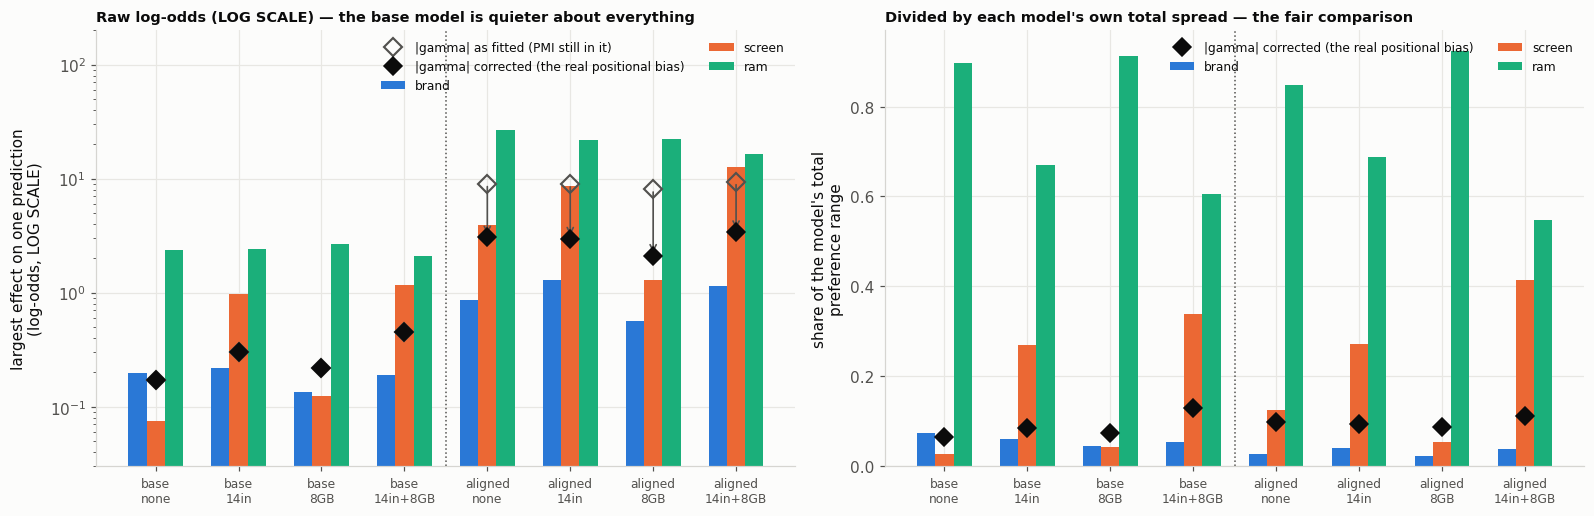

              row  g_fit  g_true      S  g_rel  brand  screen    ram
       base\nnone  0.170   0.170  2.631  0.065  0.198   0.074  2.360
       base\n14in  0.303   0.303  3.587  0.085  0.220   0.966  2.401
        base\n8GB  0.216   0.216  2.942  0.074  0.134   0.125  2.683
   base\n14in+8GB  0.449   0.449  3.446  0.130  0.188   1.168  2.089
    aligned\nnone  9.049   3.048 31.284  0.097  0.858   3.900 26.526
    aligned\n14in  8.980   2.979 31.728  0.094  1.278   8.597 21.853
     aligned\n8GB  8.106   2.106 24.111  0.087  0.561   1.282 22.269
aligned\n14in+8GB  9.396   3.396 30.199  0.112  1.139  12.526 16.535

relative positional bias |gamma|/S, mean per kind:
kind
aligned    0.098
base       0.088


In [8]:
piv = pd.DataFrame([
    dict(row=f"{kind}\n{CLAB[c]}", kind=kind, contract=CLAB[c],
         **{f: FITS[KEY[(kind, c)]].range(f) for f in LEVELS},
         g_fit=abs(FITS[KEY[(kind, c)]].gamma_fit_),
         g_true=abs(FITS[KEY[(kind, c)]].gamma_),
         S=FITS[KEY[(kind, c)]].total_spread())
    for kind in KINDS for c in CON])
piv["g_rel"] = piv.g_true / piv.S
for f in LEVELS:
    piv[f"{f}_rel"] = piv[f] / piv.S

fig, axes = plt.subplots(1, 2, figsize=(14.6, 4.8))

for ax, (suffix, ttl, ylab) in zip(axes, [
        ("", "Raw log-odds (LOG SCALE) — the base model is quieter about everything",
         "largest effect on one prediction\n(log-odds, LOG SCALE)"),
        ("_rel", "Divided by each model's own total spread — the fair comparison",
         "share of the model's total\npreference range")]):
    x = np.arange(len(piv))
    for i, ft in enumerate(["brand", "screen", "ram"]):
        ax.bar(x + (i - 1) * .22, piv[ft + suffix], .22, color=FEATURE_COLOR[ft],
               label=ft, zorder=2)
    gt = piv.g_true if suffix == "" else piv.g_rel
    if suffix == "":
        ax.plot(x, piv.g_fit, "D", mfc="none", mec=INK_MUTED, mew=1.4, ms=8, ls="none",
                label="|gamma| as fitted (PMI still in it)", zorder=4)
        for xi, (lo, hi) in enumerate(zip(gt, piv.g_fit)):
            if abs(hi - lo) > 1e-9:
                ax.annotate("", xy=(xi, lo), xytext=(xi, hi),
                            arrowprops=dict(arrowstyle="->", color=INK_MUTED, lw=1.1))
        ax.set_yscale("log")
        ax.set_ylim(0.03, 200)
    ax.plot(x, gt, "D", color=INK, ms=8, ls="none",
            label="|gamma| corrected (the real positional bias)", zorder=5)
    ax.axvline(3.5, color=INK_MUTED, lw=1, ls=":")
    ax.set_xticks(x, piv.row, fontsize=8)
    ax.set_ylabel(ylab)
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=9.5)
    ax.legend(frameon=False, fontsize=8, ncol=2)

fig.tight_layout()
save(fig, "pt3_gamma_vs_features")
plt.show()

print(piv[["row", "g_fit", "g_true", "S", "g_rel", "brand", "screen", "ram"]]
      .round(3).to_string(index=False))
print("\nrelative positional bias |gamma|/S, mean per kind:")
print(piv.groupby("kind").g_rel.mean().round(3).to_string())

---
# Fig PT-4 — the comparison: same preferences, different volume

Every weight of both models, plotted against each other. **One point = one (feature, level,
contract)**: 11 levels x 4 contracts = 44 points. Axes are the normalised weight $\tilde{w}$,
so a point on the diagonal means the two models give that level the same share of their total
preference range.

**Left panel** is the scale-free comparison. **Right panel** is what is being divided out: the
total spread $S$ per contract, which is where base and aligned actually differ.

If instruction tuning *created* these preferences, the left panel would be a cloud. If it only
turned up the volume, the left panel is the diagonal and the right panel carries the whole
difference.

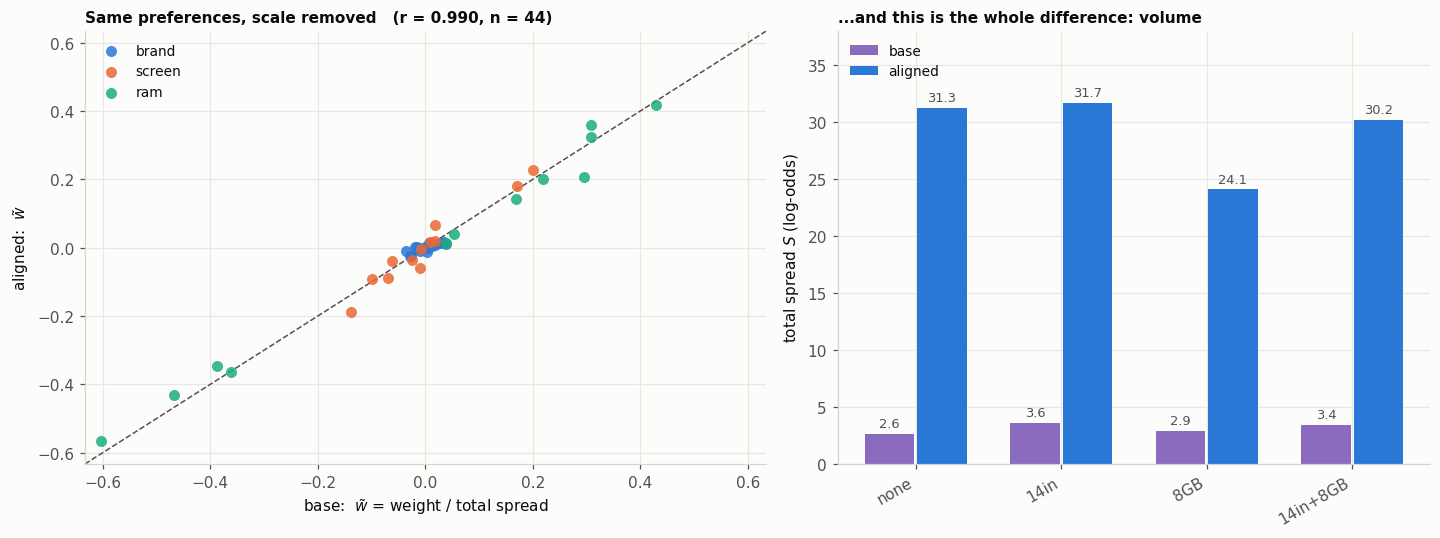

agreement between base and aligned, per contract:

contract  r_all11  r_brand  S_base  S_aligned  loudness
    none    0.990    0.645   2.631     31.284    11.890
    14in    0.997    0.842   3.587     31.728     8.846
     8GB    0.989    0.772   2.942     24.111     8.197
14in+8GB    0.989    0.932   3.446     30.199     8.765

overall r over all 44 weights: 0.990
brand is the weakest agreement - it is also the smallest feature, so the noisiest.


In [9]:
pts = []
for c in CON:
    for f, lvls in LEVELS.items():
        for l in lvls:
            pts.append(dict(contract=CLAB[c], feature=f, level=l,
                            base=FITS[KEY[("base", c)]].normalised(f, l),
                            aligned=FITS[KEY[("aligned", c)]].normalised(f, l)))
P = pd.DataFrame(pts)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
lim = 1.05 * max(P.base.abs().max(), P.aligned.abs().max())
ax.plot([-lim, lim], [-lim, lim], color=INK_MUTED, lw=1, ls="--", zorder=1)
for f in LEVELS:
    s = P[P.feature == f]
    ax.scatter(s.base, s.aligned, s=52, color=FEATURE_COLOR[f], label=f,
               alpha=.85, linewidths=0, zorder=3)
r_all = np.corrcoef(P.base, P.aligned)[0, 1]
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("base:  $\\tilde{w}$ = weight / total spread")
ax.set_ylabel("aligned:  $\\tilde{w}$")
ax.set_title(f"Same preferences, scale removed   (r = {r_all:.3f}, n = {len(P)})",
             loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9, loc="upper left")

ax = axes[1]
x = np.arange(len(CON))
for i, kind in enumerate(KINDS):
    S = [FITS[KEY[(kind, c)]].total_spread() for c in CON]
    ax.bar(x + (i - .5) * .36, S, .34, color=KIND_COLOR[kind], label=kind, zorder=2)
    for xi, v in zip(x + (i - .5) * .36, S):
        ax.text(xi, v + .6, f"{v:.1f}", ha="center", fontsize=8.5, color=INK_MUTED)
ax.set_xticks(x, cols, rotation=30, ha="right")
ax.set_ylabel("total spread $S$ (log-odds)")
ax.set_title("...and this is the whole difference: volume", loc="left",
             fontweight="bold", fontsize=10)
ax.set_ylim(0, 38)
ax.legend(frameon=False, fontsize=9, loc="upper left")

fig.tight_layout()
save(fig, "pt4_base_vs_aligned")
plt.show()

print("agreement between base and aligned, per contract:\n")
agree = []
for c in CON:
    s = P[P.contract == CLAB[c]]
    sb = P[(P.contract == CLAB[c]) & (P.feature == "brand")]
    agree.append(dict(contract=CLAB[c],
                      r_all11=np.corrcoef(s.base, s.aligned)[0, 1],
                      r_brand=np.corrcoef(sb.base, sb.aligned)[0, 1],
                      S_base=FITS[KEY[("base", c)]].total_spread(),
                      S_aligned=FITS[KEY[("aligned", c)]].total_spread()))
AG = pd.DataFrame(agree)
AG["loudness"] = AG.S_aligned / AG.S_base
print(AG.round(3).to_string(index=False))
print(f"\noverall r over all {len(P)} weights: {r_all:.3f}")
print("brand is the weakest agreement - it is also the smallest feature, so the noisiest.")